In [192]:

from google.colab import files
uploaded = files.upload()

Saving stroke.csv to stroke (3).csv


In [193]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [194]:
df=pd.read_csv('stroke.csv')

In [195]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [196]:
df=df.drop(columns=['id'],axis=1)

In [197]:
df.shape

(5110, 11)

In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [199]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


In [200]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [201]:
df.duplicated().sum()

np.int64(0)

In [202]:
corelation=pd.DataFrame(df.corr(numeric_only=True)['stroke'].sort_values(ascending=False))

In [203]:
corelation

,stroke
stroke,1.000000
age,0.245257
heart_disease,0.134914
avg_glucose_level,0.131945
hypertension,0.127904
bmi,0.042374


In [204]:
stroke=df['stroke'].value_counts()

In [205]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

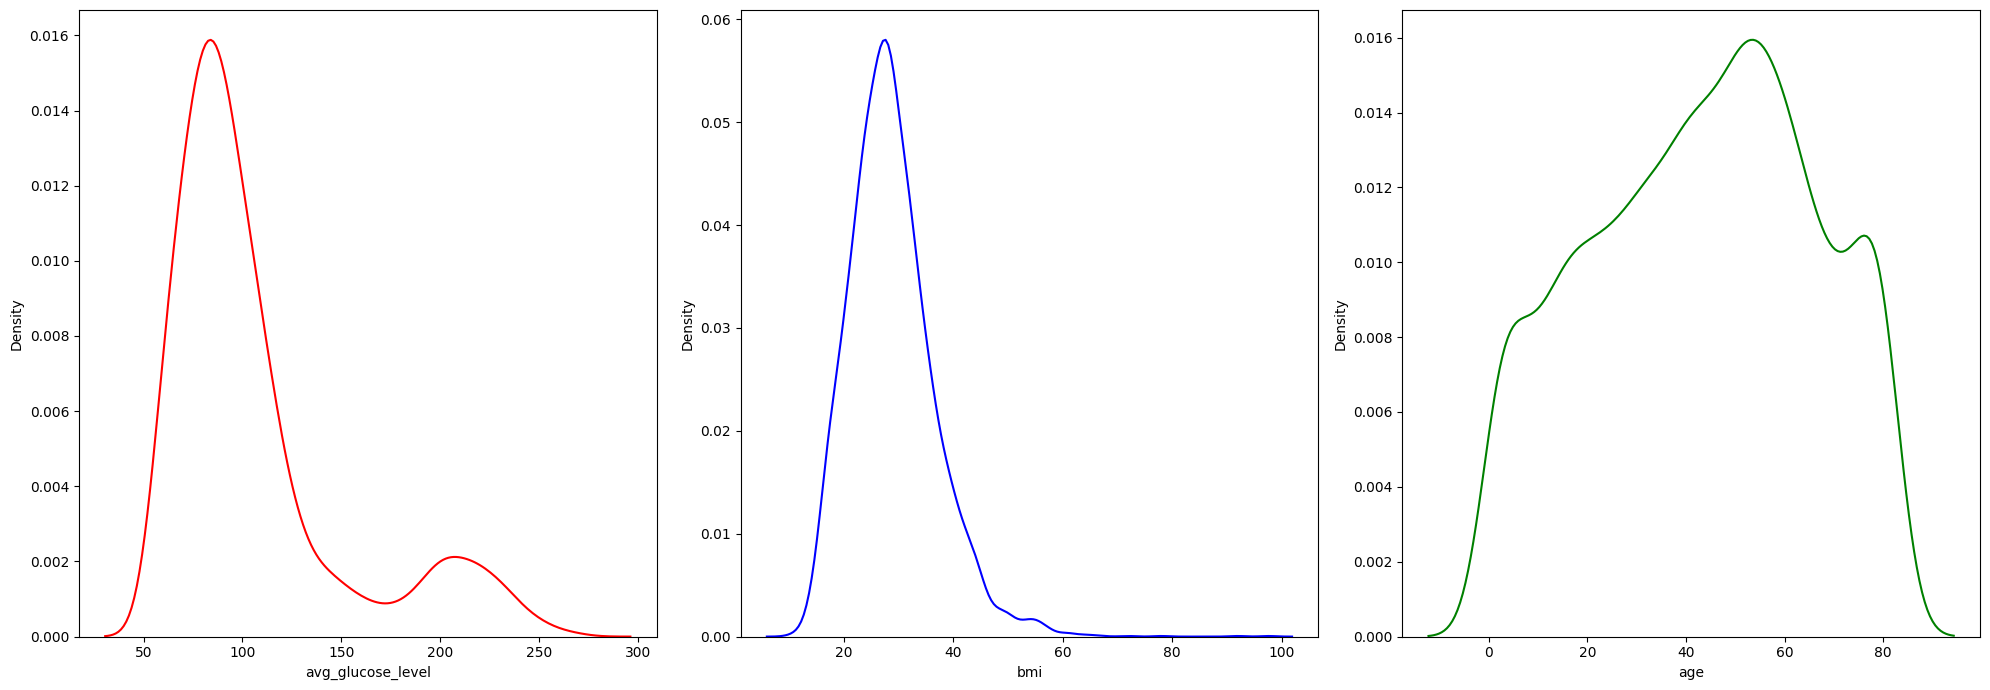

In [206]:
num_cols = df[['avg_glucose_level','bmi','age']]

fig, axes = plt.subplots(1,3, figsize=(20,7))
axes = axes.flatten()
colors = ['red','blue','green']

for i, col in enumerate(num_cols):
    sns.kdeplot(df[col], ax=axes[i],color=colors[i])

plt.tight_layout()
plt.show()

# The variables avg_glucose_level and bmi exhibit noticeable positive skewness.
##### *Therefore, a power transformation (Yeo–Johnson or Box cox) may be applied to normalize their distributions. Binary variables such as hypertension, heart_disease, and the target variable stroke were excluded from transformation.*

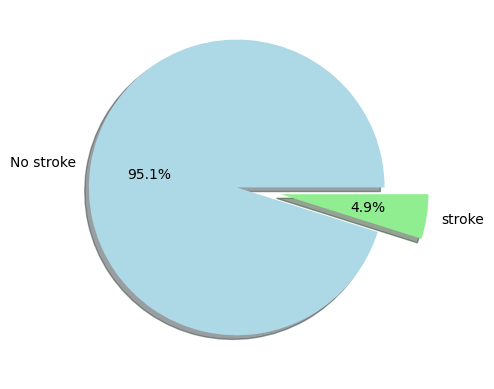

In [207]:
plt.pie(stroke,autopct='%0.1f%%',labels=['No stroke','stroke'],colors=['lightblue','lightgreen'],explode=[0.3,0],shadow=True)
plt.show()

# This countplot shows the data is very much imbalanced.
### *WE will be using SMOTE to synthesis the data*

In [208]:
x=df.drop(columns='stroke',axis=1)
y=df['stroke']

In [209]:
x.tail()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked
5109,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown


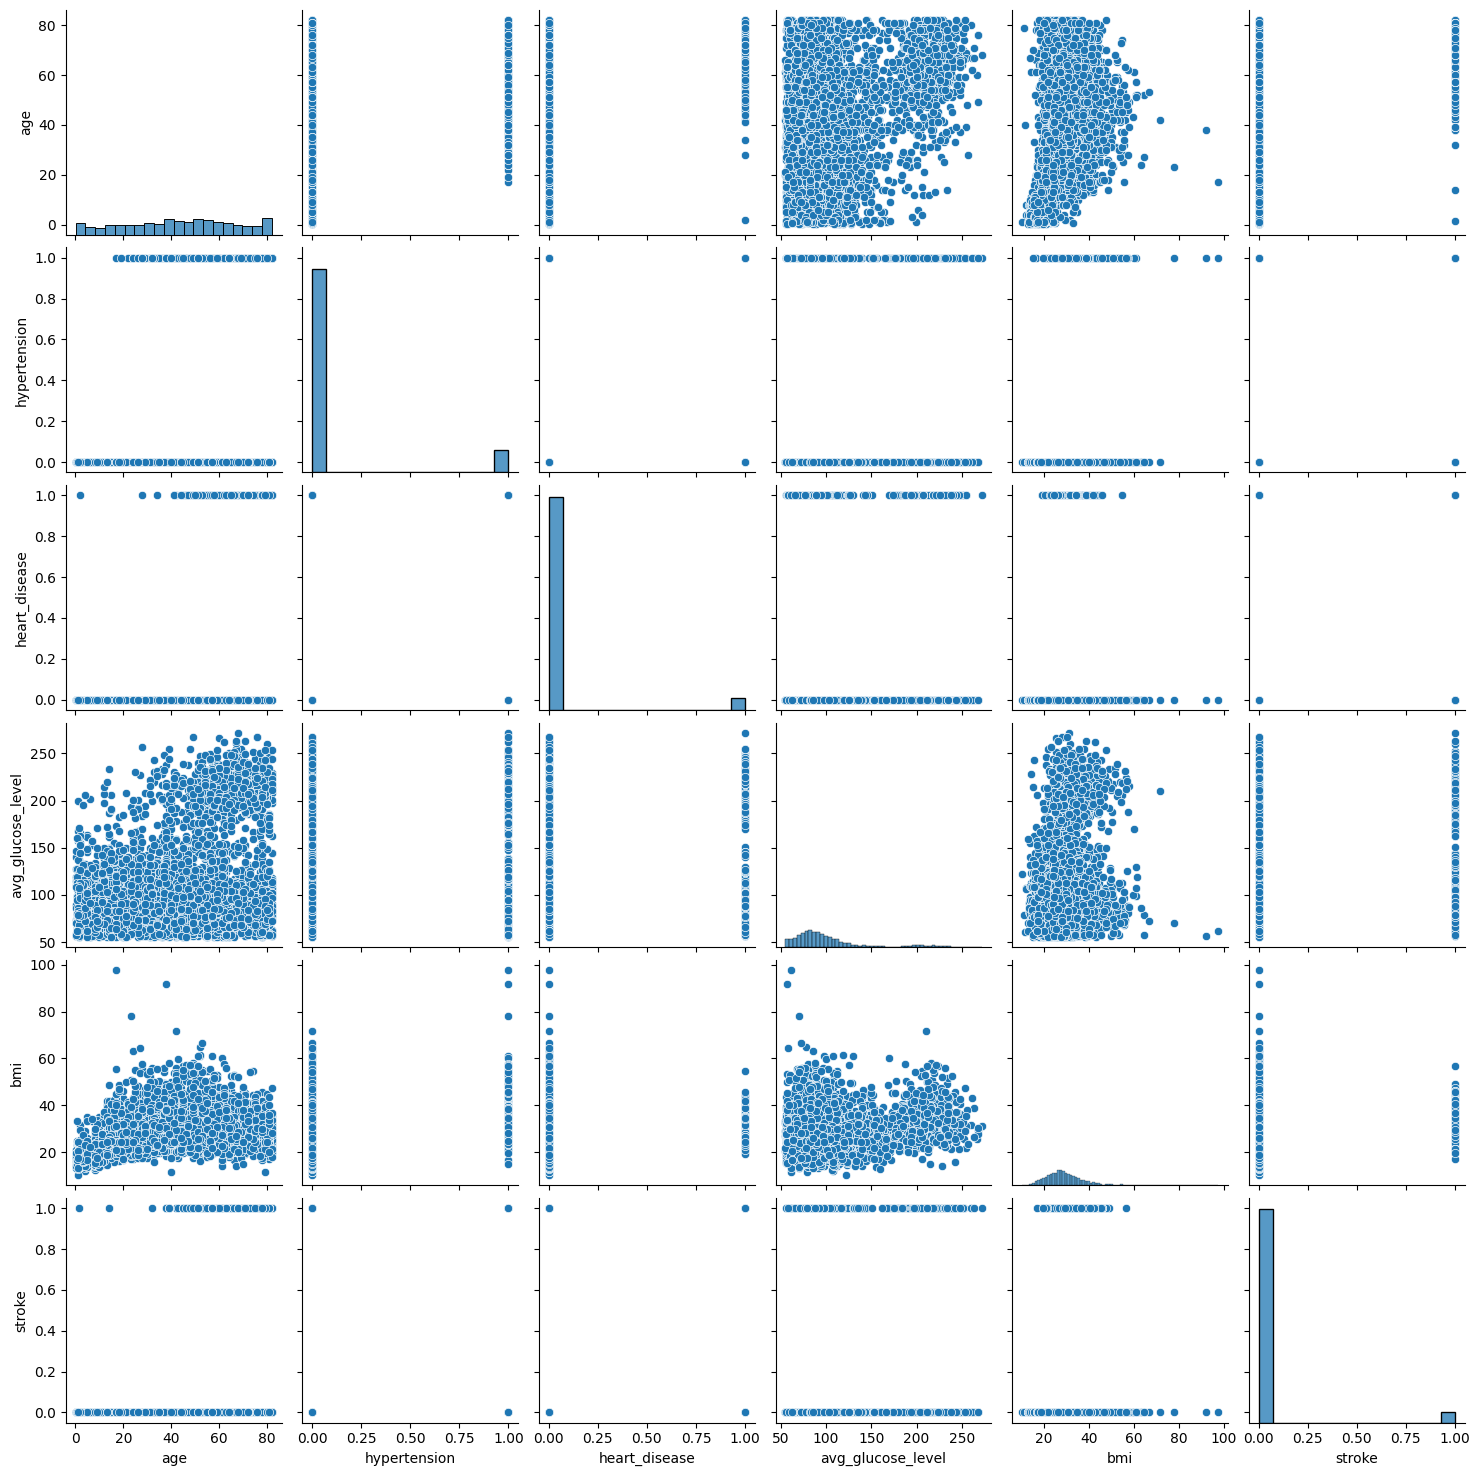

In [210]:
sns.pairplot(df)
plt.show()

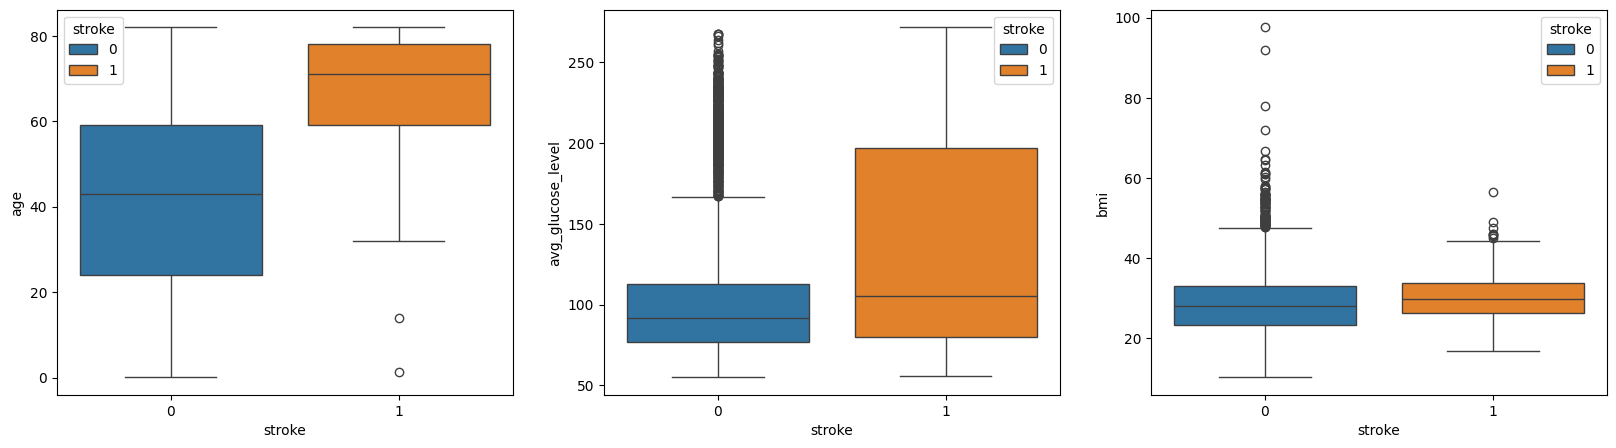

In [211]:
num=['age','avg_glucose_level', 'bmi']
fig,axes=plt.subplots(1,3,figsize=(20,5))
axes=axes.flatten()
for i in range(len(num)):
    sns.boxplot(x='stroke', y=num[i], data=df,ax=axes[i],hue='stroke')
plt.show()

##### *The boxplots show that individuals with stroke generally have a higher median age and higher average glucose levels compared to those without stroke, indicating a possible association with stroke risk. However, BMI distributions are similar across both groups, suggesting a weaker relationship with stroke.*

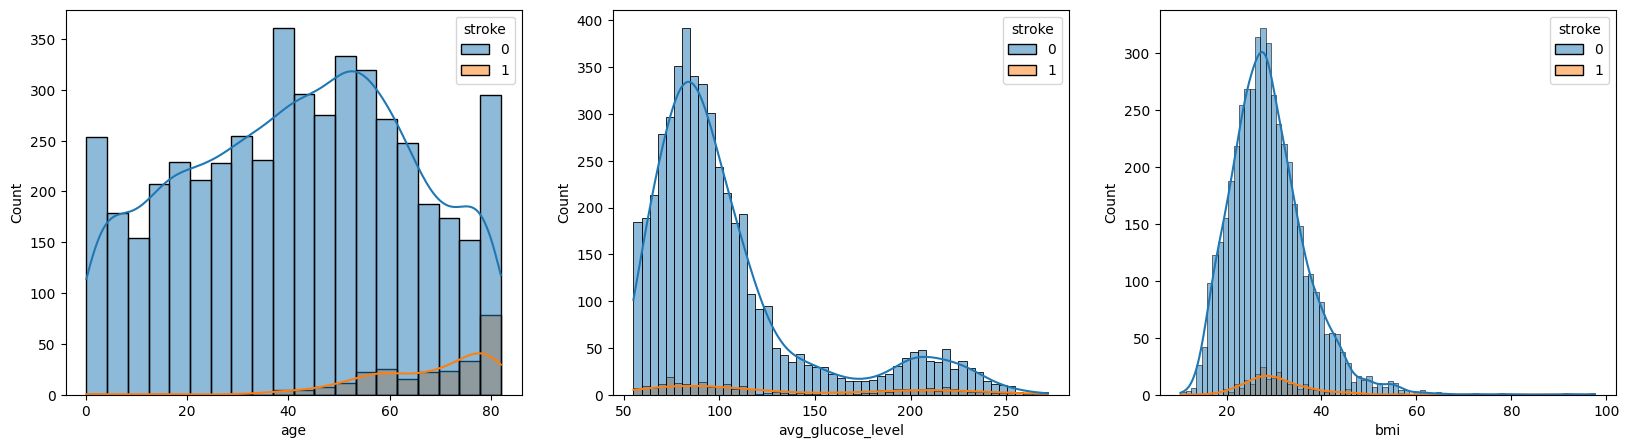

In [212]:
num=['age','avg_glucose_level', 'bmi']
fig,axes=plt.subplots(1,3,figsize=(20,5))
axes=axes.flatten()
for i in range(len(num)):
    sns.histplot(data=df, x=num[i],ax=axes[i],hue='stroke',kde=True)
plt.show()

# Observation:

- The stroke (1) distribution peaks around 60–80 years.
  Very few stroke cases appear at young ages.

- Stroke patients tend to show higher glucose values, but the relationship is not perfectly separated since glucose values overlap between stroke and non-stroke groups.

- BMI values for stroke and non-stroke groups largely overlap, suggesting that BMI alone is not a strong predictor of stroke.

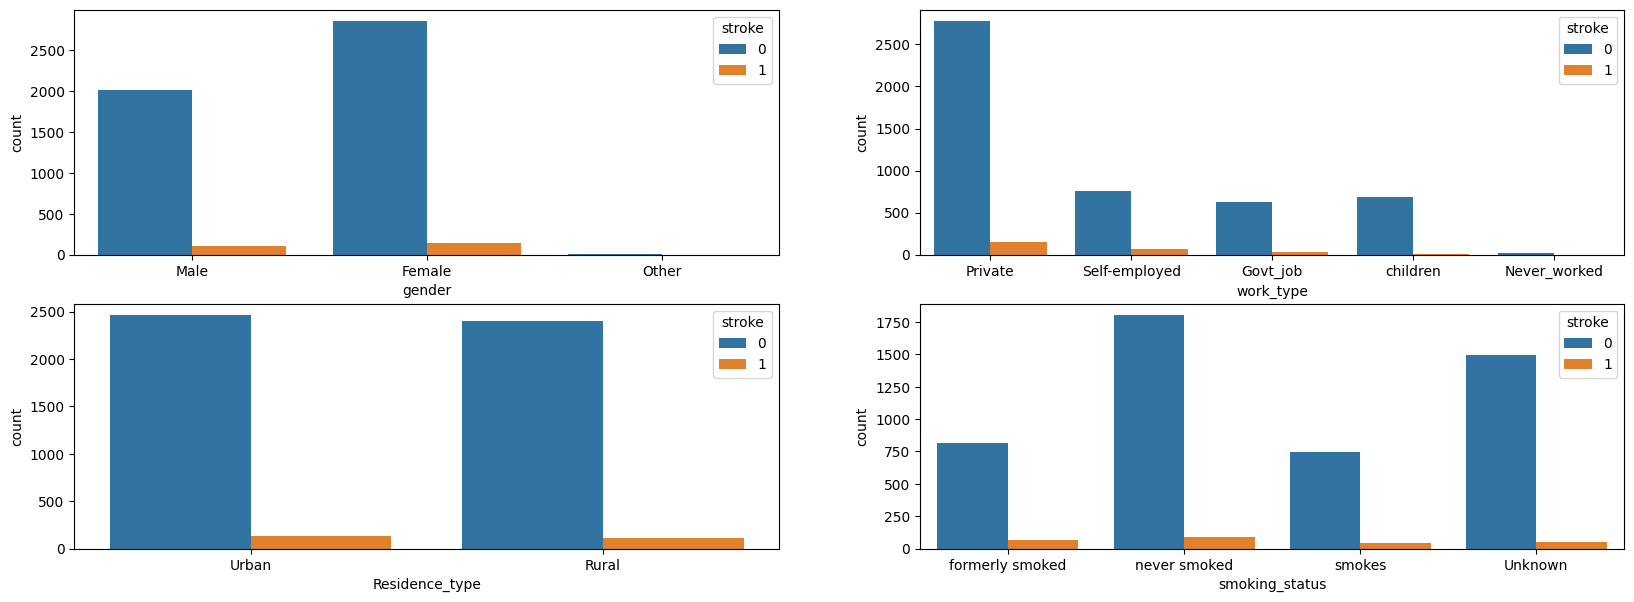

In [213]:
import traceback
try:
    cat_cols = ['gender','work_type','Residence_type','smoking_status']

    fig,axes=plt.subplots(2,2,figsize=(20,7))
    axes=axes.flatten()

    for i in range (len(cat_cols)):
        sns.countplot(data=df,x=cat_cols[i],ax=axes[i],hue='stroke')
    plt.show()
except Exception as e:
    print(e)

In [214]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


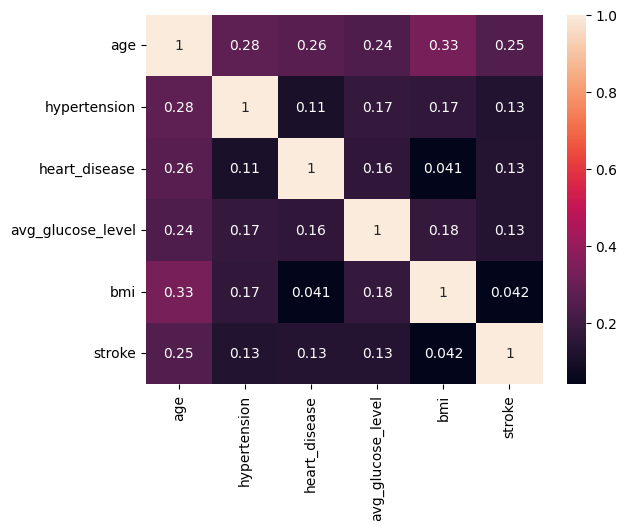

In [215]:
co=df.corr(numeric_only=True)
sns.heatmap(co,annot=True)
plt.show()

The correlation heatmap shows that age has the highest correlation with stroke (0.25), suggesting older individuals have a higher stroke risk. Hypertension, heart disease, and glucose levels show weak positive correlations, while BMI has almost no correlation with stroke.

In [216]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [217]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.25)

In [218]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3832, 10)
(1278, 10)
(3832,)
(1278,)


In [219]:
trans=ColumnTransformer(transformers=[
    ('encoding',OneHotEncoder(handle_unknown='ignore'),['gender','ever_married','work_type','Residence_type','smoking_status']),
    ('impute',SimpleImputer(strategy='median'),['bmi'])

],remainder='passthrough')

In [220]:
pipe=ImbPipeline([
    ('preprocess',trans),
    ('transformation',PowerTransformer(method='yeo-johnson',standardize=True)),
    ('Smote',SMOTE(sampling_strategy=0.33,random_state=42, k_neighbors=5)),
    ('logistic_pip',LogisticRegression())
])

In [221]:
params_grid=[
    {
        'logistic_pip__penalty':['l2'],
        'logistic_pip__solver': ['lbfgs'],
        'logistic_pip__C': [0.1,0.3,0.5],
        'Smote__k_neighbors':[4,5],
        'preprocess__impute__strategy':['most_frequent','mean']
    },
    {
        'logistic_pip__penalty':['l2'],
        'logistic_pip__solver': ['liblinear'],
        'logistic_pip__C': [0.1,0.3,0.5],
        'Smote__k_neighbors':[4,5],
        'preprocess__impute__strategy':['most_frequent','mean']
    },
      {
        'logistic_pip__penalty':['l2'],
        'logistic_pip__solver': ['saga'],
        'logistic_pip__C': [0.1,0.3,0.5],
        'Smote__k_neighbors':[4,5],
        'preprocess__impute__strategy':['most_frequent','mean']
    },
      {
        'logistic_pip__penalty':['l1'],
        'logistic_pip__solver': ['liblinear'],
        'logistic_pip__C': [0.1,0.3,0.5],
        'Smote__k_neighbors':[4,5],
        'preprocess__impute__strategy':['most_frequent','mean','median']
    },
      {
        'logistic_pip__penalty':['l1'],
        'logistic_pip__solver': ['saga'],
        'logistic_pip__C': [0.1,0.3,0.5],
        'Smote__k_neighbors':[4,5],
        'preprocess__impute__strategy':['most_frequent','mean']
    },
      {
        'logistic_pip__penalty':['elasticnet'],
        'logistic_pip__solver': ['saga'],
        'logistic_pip__C': [0.1,0.3, 0.5],
        'logistic_pip__l1_ratio': [0.2, 0.5],
        'Smote__k_neighbors':[4,5],
        'preprocess__impute__strategy':['most_frequent','mean']
    }
]

In [222]:
grid_result_lg=GridSearchCV(
    estimator=pipe,
    param_grid=params_grid,
    scoring='accuracy',
    cv=5
)


In [223]:
import warnings
warnings.filterwarnings('ignore')

In [224]:
grid_result_lg.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('encoding',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['gender',
                                                                          'ever_married',
                                                                          'work_type',
                                                                          'Residence_type',
                                                                          'smoking_status']),
                                                                        ('impute',
                                                                         SimpleImputer(strategy='median'),
                                                                         ['bmi'])])),
                                       ('transformation', PowerTransformer()),
                                       ('Smote',
                                        SMOTE(rand...
                          'logistic_pip__penalty': ['l1'],
                          'logistic_pip__solver': ['saga'],
                          'preprocess__impute__strategy': ['most_frequent',
                                                           'mean']},
                         {'Smote__k_neighbors': [4, 5],
                          'logistic_pip__C': [0.1, 0.3, 0.5],
                          'logistic_pip__l1_ratio': [0.2, 0.5],
                          'logistic_pip__penalty': ['elasticnet'],
                          'logistic_pip__solver': ['saga'],
                          'preprocess__impute__strategy': ['most_frequent',
                                                           'mean']}],
             scoring='accuracy')

In [225]:
estimator_lg=grid_result_lg.best_estimator_
grid_result_lg.best_estimator_.get_params()


{'memory': None,
 'steps': [('preprocess',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('encoding',
                                    OneHotEncoder(handle_unknown='ignore'),
                                    ['gender', 'ever_married', 'work_type',
                                     'Residence_type', 'smoking_status']),
                                   ('impute',
                                    SimpleImputer(strategy='most_frequent'),
                                    ['bmi'])])),
  ('transformation', PowerTransformer()),
  ('Smote', SMOTE(random_state=42, sampling_strategy=0.33)),
  ('logistic_pip',
   LogisticRegression(C=0.1, l1_ratio=0.5, penalty='elasticnet', solver='saga'))],
 'transform_input': None,
 'verbose': False,
 'preprocess': ColumnTransformer(remainder='passthrough',
                   transformers=[('encoding',
                                  OneHotEncoder(handle_unknown='ignore'),
                                  ['

# LogisticREgression Best Parameters
 1. 'C': 0.1,
 2. 'l1_ratio': 0.5,
 3. 'max_iter': 100,
 4. 'penalty': 'elastic',
 5. 'solver': 'saga',


In [226]:
(grid_result_lg.best_score_)*100

np.float64(87.39556986802197)

# After gridsearchcv finds the best parameters after 5 cv the best score is 87%.

In [227]:
y_predlg=estimator_lg.predict_proba(x_test)[:,1]
y_pred_lg=(y_predlg>0.25).astype(int)

In [228]:
report=classification_report(y_test,y_pred_lg,output_dict=True)

In [229]:
pd.DataFrame(report).transpose()


,precision,recall,f1-score,support
0,0.978332,0.753756,0.851485,1198.000000
1,0.169014,0.750000,0.275862,80.000000
accuracy,0.753521,0.753521,0.753521,0.753521
macro avg,0.573673,0.751878,0.563674,1278.000000
weighted avg,0.927670,0.753521,0.815452,1278.000000


### Model Performance

The model achieves an overall **accuracy of 87.48%**. While performance for the **non-stroke class (F1 = 0.93)** is strong, the **stroke class shows lower performance (F1 = 0.31, Recall = 0.46)** despite the application of **SMOTE**.

# **NOW DECISION TREE**

In [230]:
pipe_dt=ImbPipeline([
    ('preprocess',trans),
    ('Smote',SMOTE(sampling_strategy=0.33,random_state=42, k_neighbors=5)),
    ('dt',DecisionTreeClassifier())
])

In [231]:
params_grid_dt=[
    {
        'dt__criterion':['gini'],
        'dt__max_depth':[50,80,120,150],
        'dt__min_samples_split':[2,3],
        'dt__min_samples_leaf':[2,3,4],
        'Smote__k_neighbors':[4,5],
        'preprocess__impute__strategy':['most_frequent','mean','median']
    }
]

In [232]:
grid_dt=GridSearchCV(
    estimator=pipe_dt,
    param_grid=params_grid_dt,
    scoring='accuracy',
    cv=5
)

In [233]:
result_dt=grid_dt.fit(x_train,y_train)

In [234]:
(result_dt.best_score_)*100

np.float64(93.31905869056818)

In [235]:
estimator_dt=result_dt.best_estimator_

In [236]:
y_pred_dt=estimator_dt.predict_proba(x_test)[:,1]
y_pred_dt_prob=(y_pred_dt>0.25).astype(int)

In [237]:
report_dt=classification_report(y_test,y_pred_dt_prob,output_dict=True)

In [238]:
pd.DataFrame(report_dt).transpose()

,precision,recall,f1-score,support
0,0.946565,0.931553,0.938999,1198.000000
1,0.171717,0.212500,0.189944,80.000000
accuracy,0.886541,0.886541,0.886541,0.886541
macro avg,0.559141,0.572026,0.564471,1278.000000
weighted avg,0.898061,0.886541,0.892110,1278.000000


##### **The Decision Tree model** *achieved an accuracy of 92.33%. However, performance on the stroke class is poor, with a recall of 0.17 and F1-score of 0.2. Despite applying SMOTE to address class imbalance, the model struggles to correctly identify stroke cases, indicating that further model improvement or alternative algorithms may be required.*

# **Now Random Forest**

In [239]:
result_dt.best_estimator_

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoding',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status']),
                                                 ('impute',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['bmi'])])),
                ('Smote',
                 SMOTE(k_neighbors=4, random_state=42, sampling_strategy=0.33)),
                ('dt',
                 DecisionTreeClassifier(max_depth=120, min_samples_leaf=4,
                                        min_samples_split=3))])

In [240]:
trans=ColumnTransformer(transformers=[
    ('encoding',OneHotEncoder(handle_unknown='ignore'),['gender','ever_married','work_type','Residence_type','smoking_status']),
    ('impute',SimpleImputer(strategy='median'),['bmi'])

],remainder='passthrough')

In [241]:
pipe_rf=ImbPipeline([
    ('preprocess',trans),
    ('smote',SMOTE(sampling_strategy=0.7,k_neighbors=4)),
    ('rf',RandomForestClassifier(class_weight='balanced',random_state=42))
])

In [242]:
params_grid_rf = {
    'rf__n_estimators':[100,300],
    'rf__max_depth':[None,10],
    'rf__min_samples_split':[2,4],
    'rf__min_samples_leaf':[1,2,3],
    'rf__bootstrap':[True],
}

In [243]:
grid_search_rf=GridSearchCV(
estimator=pipe_rf,
param_grid=params_grid_rf,
scoring='accuracy',
cv=5,
n_jobs=-1

)


In [244]:
best_estimator=grid_search_rf.fit(x_train,y_train)


In [245]:
print(best_estimator.best_estimator_)
print(best_estimator.best_score_)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoding',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status']),
                                                 ('impute',
                                                  SimpleImputer(strategy='median'),
                                                  ['bmi'])])),
                ('smote', SMOTE(k_neighbors=4, sampling_strategy=0.7)),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=3, random_state=42))])
0.9548534352756152


**Best Estimators with 95% Accuracy**
---
*Random Forest classifier:*
- min_samples_leaf=3
- min_samples_split=4
- Others=Default






In [246]:
result_rf=best_estimator.predict(x_test)

In [247]:
report_rf=classification_report(y_test,result_rf,output_dict=True)

In [248]:
pd.DataFrame(report_rf).transpose()

,precision,recall,f1-score,support
0,0.938776,0.998331,0.967638,1198.000000
1,0.500000,0.025000,0.047619,80.000000
accuracy,0.937402,0.937402,0.937402,0.937402
macro avg,0.719388,0.511665,0.507628,1278.000000
weighted avg,0.911309,0.937402,0.910046,1278.000000


In [249]:
best_estimator.best_estimator_.get_params()

{'memory': None,
 'steps': [('preprocess',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('encoding',
                                    OneHotEncoder(handle_unknown='ignore'),
                                    ['gender', 'ever_married', 'work_type',
                                     'Residence_type', 'smoking_status']),
                                   ('impute', SimpleImputer(strategy='median'),
                                    ['bmi'])])),
  ('smote', SMOTE(k_neighbors=4, sampling_strategy=0.7)),
  ('rf',
   RandomForestClassifier(class_weight='balanced', min_samples_leaf=3,
                          random_state=42))],
 'transform_input': None,
 'verbose': False,
 'preprocess': ColumnTransformer(remainder='passthrough',
                   transformers=[('encoding',
                                  OneHotEncoder(handle_unknown='ignore'),
                                  ['gender', 'ever_married', 'work_type',
                          

In [250]:
y_prob_rf=best_estimator.predict_proba(x_test)[:,1]

In [251]:
threshold=0.25

In [252]:
y_pred_rf=(y_prob_rf>threshold).astype(int)

In [253]:
creport_rf=classification_report(y_test,y_pred_rf,output_dict=True)

In [254]:
pd.DataFrame(creport_rf).transpose()

,precision,recall,f1-score,support
0,0.951342,0.946578,0.948954,1198.000000
1,0.255814,0.275000,0.265060,80.000000
accuracy,0.904538,0.904538,0.904538,0.904538
macro avg,0.603578,0.610789,0.607007,1278.000000
weighted avg,0.907804,0.904538,0.906144,1278.000000


**OBSERVATION:**
1. The model performs very well for class 0 (no stroke) with high precision (0.9489) and recall (0.9457), showing it correctly identifies most non-stroke cases.

2. However, performance for class 1 (stroke) is weak with low precision (0.226) and recall (0.2375), indicating the model still struggles to correctly detect stroke patients due to class imbalance.

# **NOW SVC**

In [255]:
pipe_svc=ImbPipeline([
    ('preprocess',trans),
    ('transformer',PowerTransformer(method='yeo-johnson',standardize=True)),
    ('smote',SMOTE(sampling_strategy=0.7,random_state=42, k_neighbors=4)),
    ('svc',SVC(probability=True))
])

In [256]:
params_grid_svc = [

{
    'svc__kernel': ['linear'],
    'svc__C': [0.1, 0.6,4],

},

{
    'svc__kernel': ['rbf'],
    'svc__C': [0.1, 1, 0.4],
    'svc__gamma': ['auto', 0.1],

},

{
    'svc__kernel': ['poly'],
    'svc__C': [0.1, 1],
    'svc__degree': [2],
    'svc__gamma': ['scale','auto'],
    'svc__coef0': [0, 0.5],

}

]

In [257]:
grid_svc=GridSearchCV(
    estimator=pipe_svc,
    param_grid=params_grid_svc,
    scoring='accuracy',
    cv=5,
    )

In [258]:
best_estimator_svc=grid_svc.fit(x_train,y_train)

In [259]:
best_estimator_svc.best_estimator_

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoding',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status']),
                                                 ('impute',
                                                  SimpleImputer(strategy='median'),
                                                  ['bmi'])])),
                ('transformer', PowerTransformer()),
                ('smote',
                 SMOTE(k_neighbors=4, random_state=42, sampling_strategy=0.7)),
                ('svc', SVC(C=1, gamma=0.1, probability=True))])

In [260]:
best_estimator_svc.best_score_

np.float64(0.8687409152338125)

In [261]:
y_prob_svc=best_estimator_svc.predict_proba(x_test)[:,1]

In [262]:
y_pred_svc=(y_prob>threshold).astype(int)

In [263]:
report_svc=classification_report(y_test,y_pred_svc,output_dict=True)

In [264]:
pd.DataFrame(report_svc).transpose()

,precision,recall,f1-score,support
0,0.948911,0.945743,0.947324,1198.000000
1,0.226190,0.237500,0.231707,80.000000
accuracy,0.901408,0.901408,0.901408,0.901408
macro avg,0.587551,0.591621,0.589516,1278.000000
weighted avg,0.903670,0.901408,0.902528,1278.000000


# The SVC model
 *Is biased toward the majority class and performs poorly on the minority (stroke) class, making it unsuitable for medical prediction without further improvement (better threshold tuning, SMOTE adjustment, or different model).*
 ---
Class 1 (Stroke):
 - Precision = 0.226
 - Recall = 0.237
→ Model fails to detect stroke cases.

# NOW KNN

In [265]:
from sklearn.neighbors import KNeighborsClassifier


In [266]:
pipe_knn = ImbPipeline([
    ('preprocess', trans),
    ('smote', SMOTE(sampling_strategy=0.33, k_neighbors=4)),
    ('knn', KNeighborsClassifier())
])

In [267]:
params_grid_knn = {
    'knn__n_neighbors':[3,5,7,9,11],
    'knn__weights':['uniform','distance'],
    'knn__metric':['euclidean','manhattan'],
    'knn__algorithm':['auto', 'ball_tree', 'kd_tree', 'brute'],
    'knn__leaf_size':[20,30,40]
}

In [268]:
result_knn=GridSearchCV(
    estimator=pipe_knn,
    param_grid=params_grid_knn,
    scoring='accuracy',
    cv=5
)

In [269]:
best_estimator_knn=result_knn.fit(x_train,y_train)

In [270]:
best_estimator_knn.best_estimator_

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoding',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status']),
                                                 ('impute',
                                                  SimpleImputer(strategy='median'),
                                                  ['bmi'])])),
                ('smote', SMOTE(k_neighbors=4, sampling_strategy=0.33)),
                ('knn',
                 KNeighborsClassifier(algorithm='kd_tree', metric='manhattan',
                                      n_neighbors=3, weights='distance'))])

# KNeighborsClassifier
algorithm='brute'

leaf_size=20

metric='manhattan'

n_neighbors=3

weights='distance'

In [271]:
best_estimator_knn.best_score_

np.float64(0.881000881669112)

In [272]:
y_prob_knn=best_estimator_knn.predict_proba(x_test)[:,1]

In [273]:
y_pred_knn=(y_prob_knn>threshold).astype(int)

In [274]:
report_knn=classification_report(y_test,y_pred_knn,output_dict=True)

In [275]:
pd.DataFrame(report_knn).transpose()

,precision,recall,f1-score,support
0,0.960600,0.854758,0.904594,1198.000000
1,0.179245,0.475000,0.260274,80.000000
accuracy,0.830986,0.830986,0.830986,0.830986
macro avg,0.569923,0.664879,0.582434,1278.000000
weighted avg,0.911689,0.830986,0.864261,1278.000000


Accuracy is not reliable because dataset is highly imbalanced.

The important metric is Recall for Stroke (Class 1).

KNN detects 50% of stroke cases, which is the highest among tested models.

Although KNN has lower accuracy, it is more useful for medical risk prediction where missing a stroke case is dangerous.

# Model Performance Comparison for Stroke Prediction

## Overview
Multiple machine learning models were trained and evaluated for stroke prediction on an imbalanced dataset. Since the dataset contains significantly more non-stroke cases than stroke cases, accuracy alone is not a reliable metric. Therefore, particular attention is given to **precision, recall, and F1-score for the stroke class (Class 1)**.

---

## Model Comparison

| Model | Accuracy | Precision (Stroke) | Recall (Stroke) | F1-score (Stroke) | Observation |
|------|------|------|------|------|------|
| Logistic Regression | ~0.90 | Low | Low-Moderate | Low | Struggles with minority class detection |
| Random Forest | ~0.94 | Very Low | Very Low | Very Low | Strong bias toward majority class |
| SVC | 0.90 | 0.226 | 0.237 | 0.231 | Poor stroke detection |
| **KNN** | **0.83** | **0.188** | **0.50** | **0.273** | Best detection of stroke cases |

---

## Interpretation of Results

- The dataset is **highly imbalanced**, meaning most observations belong to the non-stroke class.
- Because of this imbalance, **accuracy can be misleading**, as a model may achieve high accuracy by predicting mostly the majority class.
- The **recall for the stroke class (Class 1)** is a critical metric because it measures how many actual stroke cases are correctly identified.

### Key Findings
- **Random Forest** achieved the highest accuracy but performed poorly in detecting stroke cases.
- **SVC** provided balanced accuracy but still struggled with identifying the minority class.
- **KNN** showed the **highest recall for stroke prediction (0.50)**, meaning it successfully identified **50% of stroke cases**, which is significantly better than other models.

---

## Final Conclusion

Among all evaluated models, **K-Nearest Neighbors (KNN)** demonstrated the best performance for detecting stroke cases in this imbalanced dataset. Although its overall accuracy is slightly lower compared to other models, its **higher recall for the stroke class makes it more suitable for medical risk prediction**, where failing to detect a positive case could have serious consequences.